# network_analysis function demo

In [1]:
# Import libraries
from process_improvement.charts.xmr_charts import network_analysis
from process_improvement.charts.utils import NetworkAnalysisConfig

from process_improvement.data_loader import list_example_files, load_example_data

%matplotlib inline

## Get data

In [2]:
# List example files
list_example_files()

['18650_battery_cells',
 '2170_battery_cell',
 'automated_manufacturing_part_lengths',
 'eight_machine_manufacturing_process',
 'milikans_electron_charge_observations',
 'monthly_united_states_trade_deficits_2024',
 'OP200_weekly_first_pass_yield',
 'quarterly_sales_by_region',
 'shewharts_resistance_measurements',
 'software_verification_death_to_birth_rates',
 'software_verification_resistance_measurement',
 'wafer_assembly_part_placement']

In [3]:
# Create dataframe
df = load_example_data("eight_machine_manufacturing_process")

df = df.drop(['Machine 5 - Initial'], axis=1)

df.head()

,Observation,Machine 1,Machine 2,Machine 3,Machine 4,Machine 5,Machine 6,Machine 7,Machine 8
0,1,6.64,5.97,6.20,4.59,5.96,5.34,5.50,4.87
1,2,5.07,5.48,6.22,4.13,5.69,5.83,5.65,5.15
2,3,5.13,5.58,6.57,5.36,6.03,5.28,5.90,5.58
3,4,4.75,7.28,6.77,5.78,6.40,6.28,4.78,6.24
4,5,6.11,6.14,6.58,3.49,5.65,4.97,5.21,5.55


In [4]:
# Melt the dataframe
df_melted = df.melt(
    id_vars="Observation",       # column to keep
    var_name="Machine",          # new column name for original machine columns
    value_name="Length"          # new column name for the values
)
df_melted

,Observation,Machine,Length
0,1,Machine 1,6.64
1,2,Machine 1,5.07
2,3,Machine 1,5.13
3,4,Machine 1,4.75
4,5,Machine 1,6.11
...,...,...,...
315,36,Machine 8,6.16
316,37,Machine 8,6.02
317,38,Machine 8,5.46
318,39,Machine 8,4.92


In [10]:
# Get unique Stages
unique_machines = df_melted['Machine'].unique().tolist()
unique_machines

['Machine 1',
 'Machine 2',
 'Machine 3',
 'Machine 4',
 'Machine 5',
 'Machine 6',
 'Machine 7',
 'Machine 8']

## Create list of dataframes

In [11]:
# Create list of dataframes using unique stages
df_list = [g.copy().reset_index(drop=True) for _, g in df_melted.groupby('Machine', sort=False)]

len(df_list)

8

## XmRChartConfiguration

In [12]:
# XmR chart configuration
config = NetworkAnalysisConfig(
    figsize=(15,6),
    round_value=1,
)

## XmR comparison of wafer placement stages

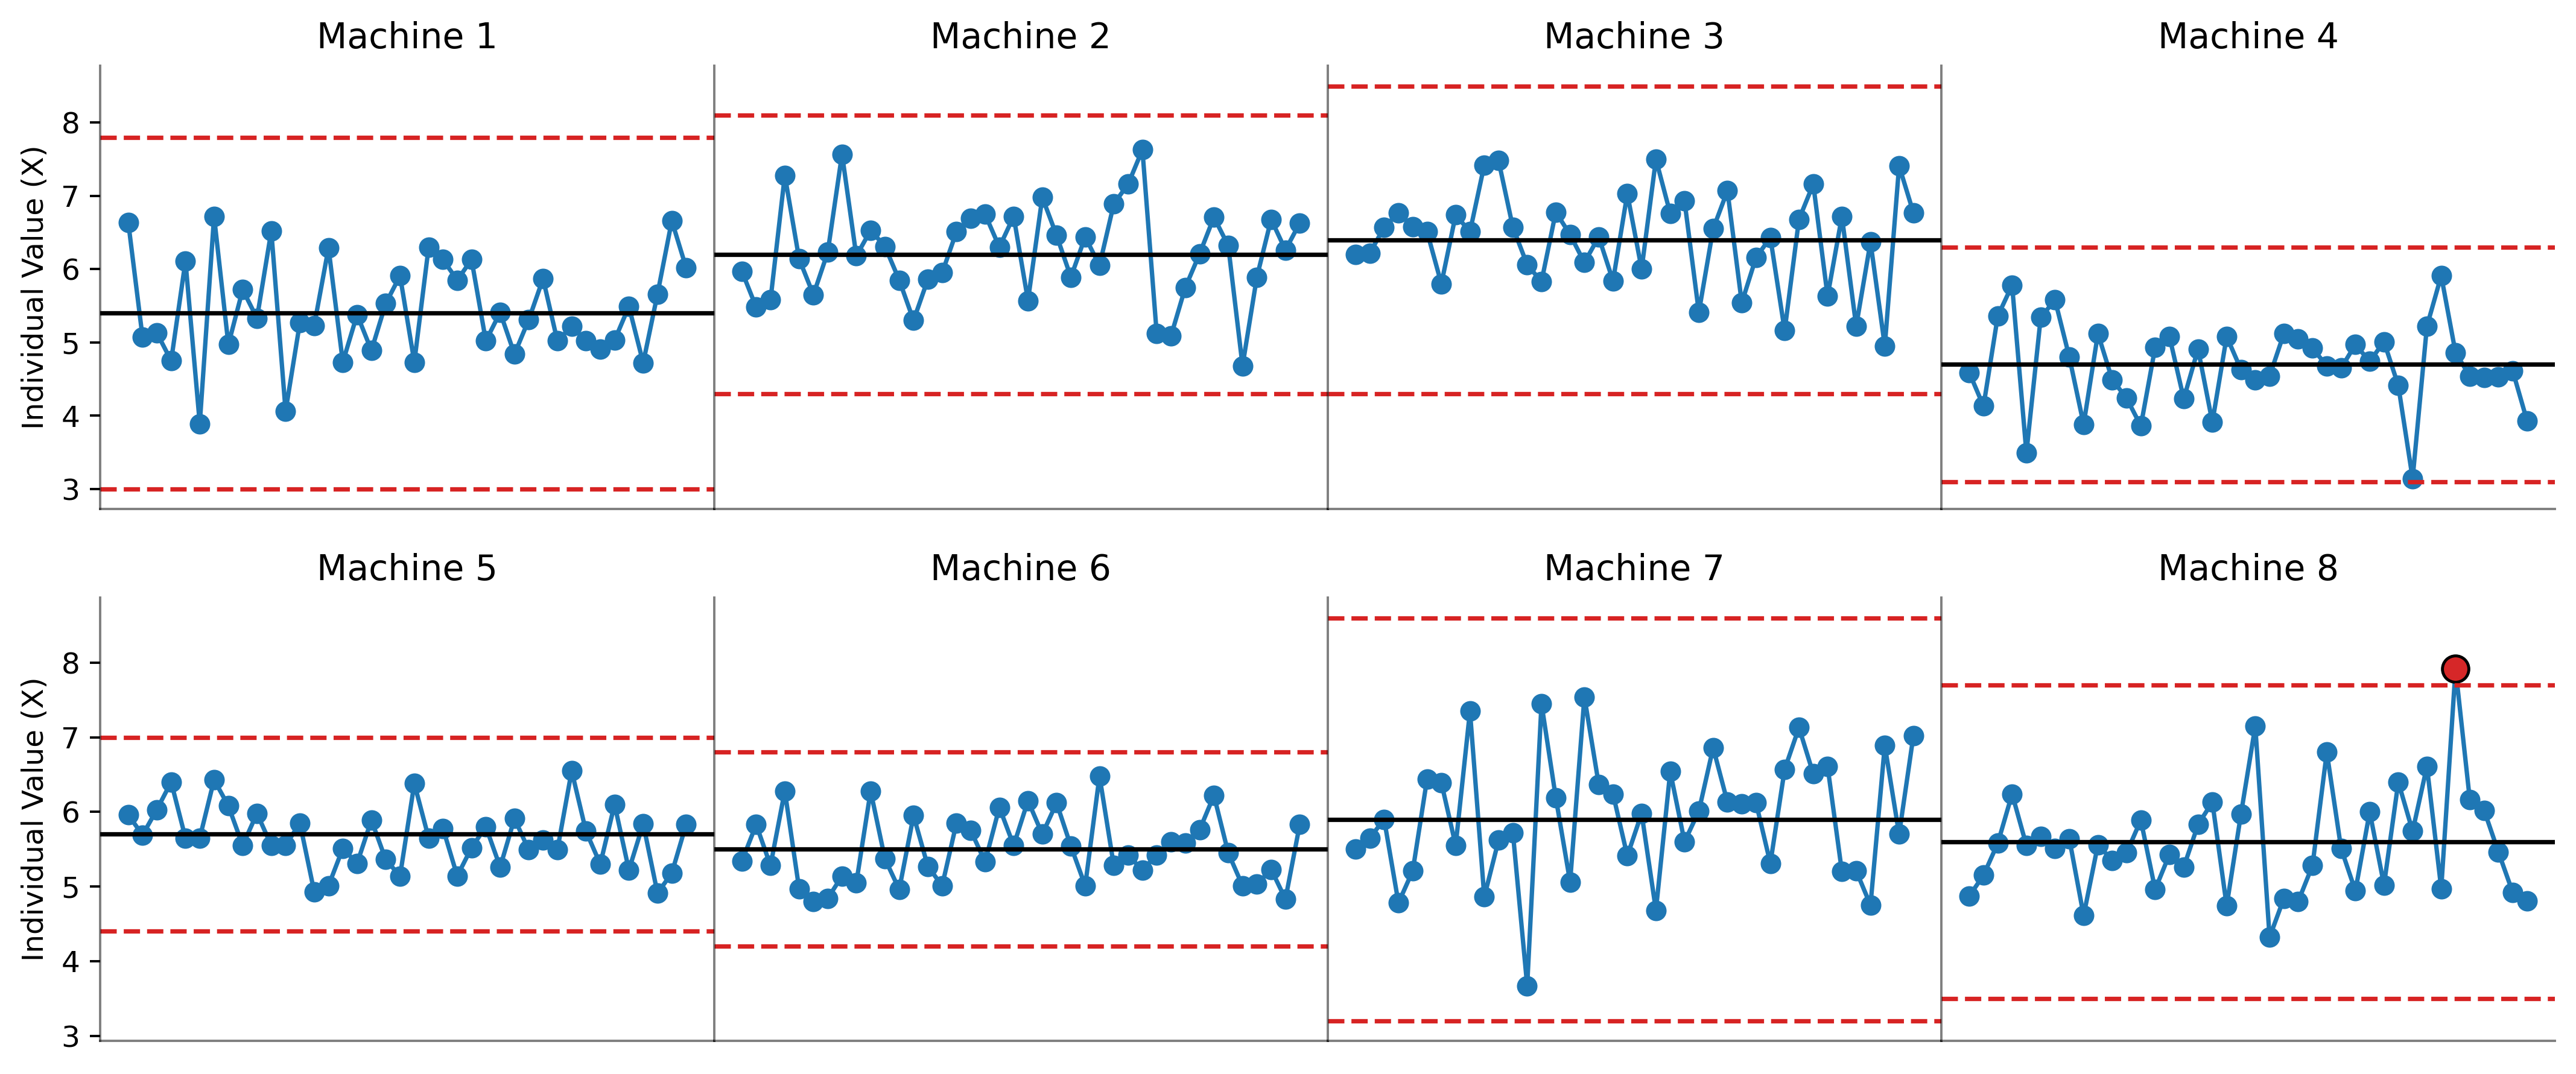

In [13]:
# Create XmR chart
results = network_analysis(
    df_list, 
    'Length', 
    nrows=2,
    ncols=4,
    subplot_titles=unique_machines,
    config=config
)

## Show process statistics

In [9]:
# Show statistics
results.stats_df

,Label,Chart,Process Stats,Values
0,Dataset 1,X chart,Mean,5.4
1,Dataset 1,X chart,UPL,7.8
2,Dataset 1,X chart,LPL,3.0
3,Dataset 1,X chart,PLR,4.8
4,Dataset 1,Overall,Characterization,Predictable
5,Dataset 2,X chart,Mean,6.2
6,Dataset 2,X chart,UPL,8.1
7,Dataset 2,X chart,LPL,4.3
8,Dataset 2,X chart,PLR,3.7
9,Dataset 2,Overall,Characterization,Unpredictable
